# Predictive Maintenance: Multiclass Failure Type Classification

This notebook demonstrates the training of baseline models (Decision Tree and Random Forest) for predicting the type of failure in predictive maintenance data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Data Loading and Preprocessing

Load the dataset and perform initial preprocessing steps including temperature conversions and feature engineering.

In [2]:
df=pd.read_csv("/Users/himeysankhe/JADS_PM_Notes/Intro ML lab/group_project/data/predictive_maintenance.csv")

In [3]:
df["Air temperature [K]"] = df["Air temperature [K]"] - 272.15
df["Process temperature [K]"] = df["Process temperature [K]"] - 272.15

# Renaming temperature in Centigrate(°C) from Kelvin (K)
df.rename(columns={"Air temperature [K]" : "Air temperature [°C]","Process temperature [K]" : "Process temperature [°C]"},inplace=True)

In [4]:
df["Temperature difference [°C]"] = df["Process temperature [°C]"] - df["Air temperature [°C]"]
df.sample(5)

,UDI,Product ID,Type,Air temperature [°C],Process temperature [°C],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Temperature difference [°C]
8065,8066,M22925,M,28.35,39.75,1670,26.3,89,0,No Failure,11.4
4722,4723,M19582,M,31.25,39.65,1391,42.7,197,0,No Failure,8.4
6077,6078,L53257,L,28.75,38.55,1479,43.3,201,0,No Failure,9.8
418,419,L47598,L,25.25,36.25,2151,17.7,0,0,No Failure,11.0
7764,7765,M22624,M,28.25,39.55,1555,38.7,5,0,No Failure,11.3


In [5]:
df = df.drop(["UDI","Product ID"],axis=1)

In [7]:
!pip install category_encoders

  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
  Using cached statsmodels-0.14.6-cp311-cp311-macosx_11_0_arm64.whl.metadata (9.5 kB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)
Using cached statsmodels-0.14.6-cp311-cp311-macosx_11_0_arm64.whl (10.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [category_encoders]statsmodels]


In [8]:
import category_encoders as ce
encoder = ce.OrdinalEncoder(cols=['Type','Failure Type'])
df = encoder.fit_transform(df)
df.head(2)

,Type,Air temperature [°C],Process temperature [°C],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Temperature difference [°C]
0,1,25.95,36.45,1551,42.8,0,0,1,10.5
1,2,26.05,36.55,1408,46.3,3,0,1,10.5


In [9]:
from sklearn.preprocessing import LabelEncoder
scaler = LabelEncoder()
df['Failure Type'] = scaler.fit_transform(df['Failure Type'])

In [11]:
X = df.drop(columns="Failure Type")
y = df["Failure Type"]

In [12]:
df.head()

,Type,Air temperature [°C],Process temperature [°C],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Temperature difference [°C]
0,1,25.95,36.45,1551,42.8,0,0,0,10.5
1,2,26.05,36.55,1408,46.3,3,0,0,10.5
2,2,25.95,36.35,1498,49.4,5,0,0,10.4
3,2,26.05,36.45,1433,39.5,7,0,0,10.4
4,2,26.05,36.55,1408,40.0,9,0,0,10.5


In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=21)

## Model Training and Evaluation

Train Decision Tree and Random Forest classifiers on the preprocessed data and evaluate their performance.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

### Random Forest Classifier

### Decision Tree Classifier

Training Accuracy    : 100.0 %
Model Accuracy Score : 99.5 %
--------------------------------------------------------
Classification_Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1921
           1       0.86      0.95      0.90        19
           2       1.00      0.67      0.80         9
           3       0.83      0.94      0.88        16
           4       0.00      0.00      0.00         3
           5       0.97      0.97      0.97        32

    accuracy                           0.99      2000
   macro avg       0.78      0.75      0.76      2000
weighted avg       0.99      0.99      0.99      2000

--------------------------------------------------------


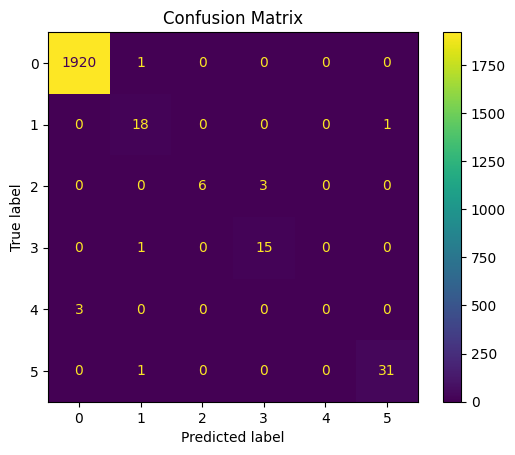

In [19]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier(n_estimators=100)
random_forest.fit(X_train, y_train)
y_pred_rf = random_forest.predict(X_test)
random_forest.score(X_train, y_train)

random_forest_train = round(random_forest.score(X_train, y_train) * 100, 2)
random_forest_accuracy = round(accuracy_score(y_pred_rf, y_test) * 100, 2)

print("Training Accuracy    :",random_forest_train ,"%")
print("Model Accuracy Score :",random_forest_accuracy ,"%")
print("\033[1m--------------------------------------------------------\033[0m")
print("Classification_Report: \n",classification_report(y_test,y_pred_rf))
print("\033[1m--------------------------------------------------------\033[0m")
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf);
plt.title('Confusion Matrix');

### Decision Tree Classifier

Training Accuracy    : 100.0 %
Model Accuracy Score : 99.3 %
--------------------------------------------------------
Classification_Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1921
           1       0.85      0.89      0.87        19
           2       0.82      1.00      0.90         9
           3       0.92      0.75      0.83        16
           4       0.00      0.00      0.00         3
           5       0.97      0.97      0.97        32

    accuracy                           0.99      2000
   macro avg       0.76      0.77      0.76      2000
weighted avg       0.99      0.99      0.99      2000

--------------------------------------------------------


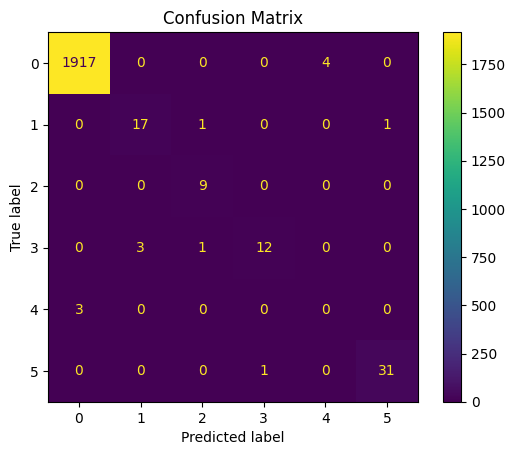

In [20]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
decision = DecisionTreeClassifier()
decision.fit(X_train, y_train)
y_pred_dec = decision.predict(X_test)

decision_train = round(decision.score(X_train, y_train) * 100, 2)
decision_accuracy = round(accuracy_score(y_pred_dec, y_test) * 100, 2)

print("Training Accuracy    :",decision_train ,"%")
print("Model Accuracy Score :",decision_accuracy ,"%")
print("\033[1m--------------------------------------------------------\033[0m")
print("Classification_Report: \n",classification_report(y_test,y_pred_dec))
print("\033[1m--------------------------------------------------------\033[0m")
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dec);
plt.title('Confusion Matrix');

In [23]:
import joblib

joblib.dump(random_forest, 'multi_prediction_random_forest.pkl')
joblib.dump(decision, 'multi_prediction_decision.pkl')

print("Encoder mapping:", encoder.mapping)
print("Scaler classes:", scaler.classes_)
print("X.shape:", X.shape)
print("X.columns:", list(X.columns))

Encoder mapping: [{'col': 'Type', 'mapping': M      1
L      2
H      3
NaN   -2
dtype: int64, 'data_type': <StringDtype(na_value=nan)>}, {'col': 'Failure Type', 'mapping': No Failure                  1
Power Failure               2
Tool Wear Failure           3
Overstrain Failure          4
Random Failures             5
Heat Dissipation Failure    6
NaN                        -2
dtype: int64, 'data_type': <StringDtype(na_value=nan)>}]
Scaler classes: [1 2 3 4 5 6]
X.shape: (10000, 8)
X.columns: ['Type', 'Air temperature [°C]', 'Process temperature [°C]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target', 'Temperature difference [°C]']
